In [1]:
# Import libraries
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

from scipy.stats import pearsonr

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

In [3]:
# Lectura de los datos estaciones meteorológicas M. de Carlos Paz
list_params = ['outTempMax', 'outTempMin', 'avg_windSpeed', 'total_rain', 'dateTime']

df_mcp = pd.read_csv('data/data_meteo_mcp_2026.csv')[list_params]
df_mcp['dateTime'] = pd.to_datetime(df_mcp['dateTime'])
df_eda = pd.read_csv('data/data_meteo_eda_2026.csv')[list_params]
df_eda['dateTime'] = pd.to_datetime(df_eda['dateTime'])


In [4]:
# Funciones para preprocesamiento datos de estaciones
def rem_outl_std(x, times=2):
    x_median = np.nanmedian(x)
    x_std = np.nanstd(x)
    
    return np.where(((x < x_median-times*x_std) | (x > x_median+times*x_std)), np.nan, x)

def rem_outl_perc(x, lower=1, upper=99):
    x_lower = np.nanpercentile(x, lower)
    x_upper = np.nanpercentile(x, upper)
    return np.where(((x < x_lower) | (x > x_upper)), np.nan, x)

def nanmedian_two(array_1, array_2):
    """Median of two arrays combined, ignoring NaNs.

    The arrays can have different shapes; both are flattened and joined.
    Returns NaN if every value is NaN.
    """
    stack = np.stack([array_1, array_2], axis=0)
    print(stack.shape)
    return np.nanmedian(stack, axis=0)

def min_max_norm(x):
    min = np.nanmin(x)
    max = np.nanmax(x)
    return (x-min)/(max-min)

## Datos de temperatura

### Temperatura estaciones

In [5]:
# Computo del promedio entre las estaciones
df_mcp['TMedn'] = nanmedian_two(rem_outl_std(np.array(df_mcp['outTempMax'])), 
              rem_outl_std(np.array(df_mcp['outTempMin'])))+273

df_eda['TMedn'] = nanmedian_two(rem_outl_std(np.array(df_eda['outTempMax'])), 
              rem_outl_std(np.array(df_eda['outTempMin'])))+273

(2, 1971)
(2, 1562)


/tmp/ipykernel_11722/2395276798.py:21: RuntimeWarning: All-NaN slice encountered
  return np.nanmedian(stack, axis=0)


### Exploración datos temperatura ERA5 data

In [6]:
# Vector ESR
esr_vector = gpd.read_file('https://github.com/francobarrionuevoenv21/MAIE_devs_pub/raw/refs/heads/main/Proc_Img/tp_final_claS2/data/esr_clean.geojson').to_crs('EPSG:4326')

# Datos temperatura era5
ds_tp = xr.open_dataset('data/reanalysis-era5-land-timeseries-sfc-2m-temperatureomkgyya2.nc')

In [7]:
# Visualizo una imagen
'''fig, ax = plt.subplots(figsize=(2, 2))
ds_tp.isel(valid_time=0).t2m.plot(a=ax)
esr_vector.dissolve().plot(ax=ax, color='red')'''

"fig, ax = plt.subplots(figsize=(2, 2))\nds_tp.isel(valid_time=0).t2m.plot(a=ax)\nesr_vector.dissolve().plot(ax=ax, color='red')"

In [8]:
# Clip datos
ds_tp = ds_tp.rio.set_spatial_dims(x_dim='longitude', y_dim='latitude', inplace=False)
ds_tp = ds_tp.rio.write_crs("EPSG:4326", inplace=False)
ds_tp_clip = ds_tp.rio.clip(esr_vector.geometry, all_touched=True)

/home/franco-barrionuevo/miniconda3/envs/sar_maie/lib/python3.14/site-packages/rasterio/features.py:381: ShapeSkipWarning: Invalid shape will not be rasterized: geometry={'type': 'MultiPolygon', 'coordinates': []}, index=0, value=1, error=ValueError('Input is not a valid geometry object')
  _rasterize(
/home/franco-barrionuevo/miniconda3/envs/sar_maie/lib/python3.14/site-packages/rasterio/features.py:381: ShapeSkipWarning: Invalid shape will not be rasterized: geometry={'type': 'MultiPolygon', 'coordinates': []}, index=1, value=1, error=ValueError('Input is not a valid geometry object')
  _rasterize(
/home/franco-barrionuevo/miniconda3/envs/sar_maie/lib/python3.14/site-packages/rasterio/features.py:381: ShapeSkipWarning: Invalid shape will not be rasterized: geometry={'type': 'MultiPolygon', 'coordinates': []}, index=2, value=1, error=ValueError('Input is not a valid geometry object')
  _rasterize(
/home/franco-barrionuevo/miniconda3/envs/sar_maie/lib/python3.14/site-packages/rasterio/

### Llenado de gaps de datos temperatura estaciones

In [9]:
# Unificación de los datos de estaciones con los de era5
df_t_join = df_mcp[['dateTime', 'TMedn']].merge(df_eda[['dateTime', 'TMedn']], on='dateTime', how="left") 
df_t_join['meanT'] = df_t_join[['TMedn_x', 'TMedn_y']].mean(axis=1)
df_t_join['yy-mm-dd'] = np.array(df_t_join['dateTime']).astype('datetime64[D]')
df_t_join = df_t_join.drop(columns=['dateTime'])

# --
tera5 = ds_tp_clip.median(dim=['latitude', 'longitude']).resample(valid_time='1D').mean()
tera5 = tera5.sel(valid_time=slice('2020-01-01', '2026-01-01'))
#df_t_era5 = pd.DataFrame({'yy-mm-dd': })

'''tera5 = ds_tp_clip.median(dim=['latitude', 'longitude']).resample(valid_time='1D').mean()
tera5 = tera5.sel(valid_time=slice('2023-01-01', '2026-01-01'))'''
df_t_era = pd.DataFrame({'yy-mm-dd': tera5.valid_time.values.astype('datetime64[D]'),
                         'eraT': tera5.t2m.values})

df_t_era_join = df_t_era.merge(df_t_join, on='yy-mm-dd', how="left") 

# --
df_t_join_plot = df_t_join[df_t_join['yy-mm-dd'] < '2026-01-01'].copy()

/tmp/ipykernel_11722/2112726571.py:4: UserWarning: no explicit representation of timezones available for np.datetime64
  df_t_join['yy-mm-dd'] = np.array(df_t_join['dateTime']).astype('datetime64[D]')


<Axes: xlabel='yy-mm-dd'>

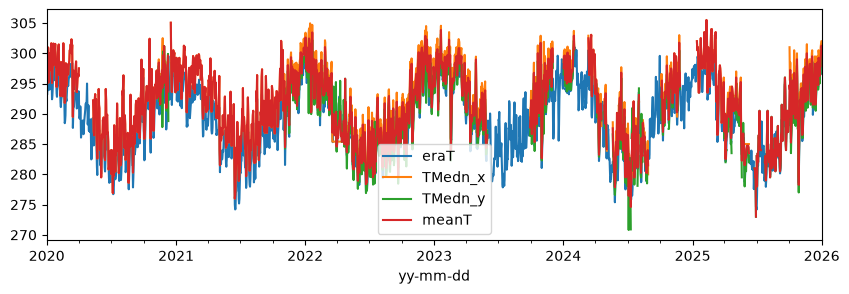

In [11]:
# Visualizo 
df_t_era_join.plot(x='yy-mm-dd', figsize=(10, 3))

In [12]:
# Evalúo correlación entre estaciones y era5
tera5_mknan = df_t_era_join['eraT'][~np.isnan(df_t_era_join['meanT'])]
tjoin_mknan = df_t_era_join['meanT'][~np.isnan(df_t_era_join['meanT'])]

# --
r, p = pearsonr(tera5_mknan, tjoin_mknan)
print(f"r = {r:.3f}, p = {p:.4f}")

r = 0.957, p = 0.0000


In [14]:
# Genero un modelo lineal para predicción de los datos en los gaps
X = np.array(tera5_mknan).reshape(-1, 1)
y = np.array(tjoin_mknan).reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
model = LinearRegression().fit(X_train, y_train)
y_pred = model.predict(X_test)

#print(f"MAE = {mean_absolute_error(y_test, y_pred):.2f}")
print(f"R² = {r2_score(y_test, y_pred):.3f}")

R² = 0.927


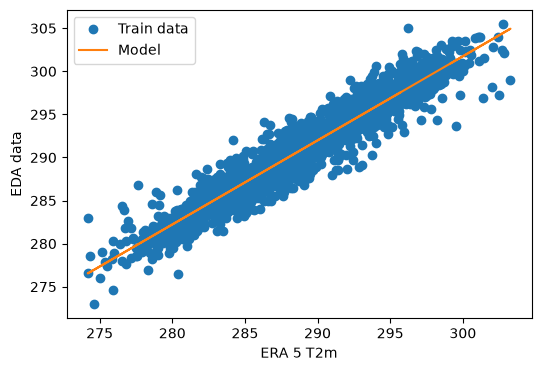

In [15]:
# Visualizo correlación
fig, ax = plt.subplots(figsize=(6, 4))

# --
ax.plot(X, tjoin_mknan, marker='o', linestyle='none', label='Train data')
ax.plot(X, model.predict(X.reshape(-1, 1)).reshape(-1), label='Model')
'''ax.plot(min_max_norm(X), min_max_norm(tjoin_mknan), marker='o', linestyle='none', label='Train data')
ax.plot(min_max_norm(X), min_max_norm(model.predict(X.reshape(-1, 1)).reshape(-1)), label='Model')
'''
# --
ax.set_xlabel('ERA 5 T2m')
ax.set_ylabel('EDA data')
ax.legend(loc='best')

In [16]:
# Enmascaro los datos y actualizo el dataset
mask = df_t_era_join['meanT'].isna()
preds = model.predict(df_t_era_join.loc[mask, 'eraT'].to_numpy().reshape(-1, 1))
df_t_era_join.loc[mask, 'meanT'] = preds

<Axes: xlabel='yy-mm-dd'>

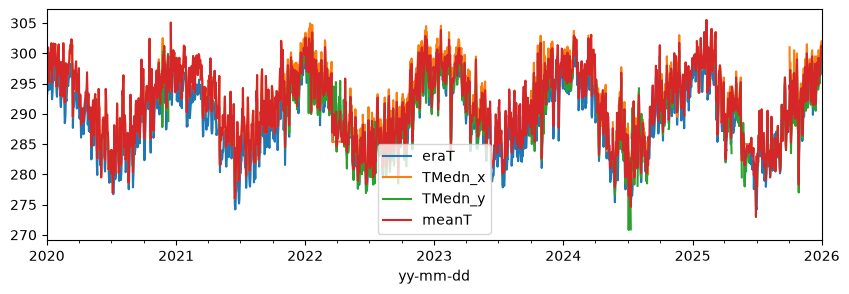

In [17]:
# Visualizo dataset final
df_t_era_join.plot(x='yy-mm-dd', figsize=(10, 3))

###  Resumen para exportar

In [47]:
# Guardo los datos finales
time_values_norm_2326 = df_t_era_join['yy-mm-dd']
tp_values_era5_2326 = df_t_era_join['eraT']
tp_values_eda_2326 = df_t_era_join['meanT']

# --
print(time_values_norm_2326.shape, tp_values_era5_2326.shape, tp_values_eda_2326.shape)

(2193,) (2193,) (2193,)


## Data de precipitación

### Precipitación estaciones

In [19]:
# Remuevo outliers y computo media entre estaciones
df_eda['total_rain'] = rem_outl_std(np.array(df_eda['total_rain']))
df_mcp['total_rain'] = rem_outl_std(np.array(df_mcp['total_rain']))

# --
df_p_join = df_mcp[['dateTime', 'total_rain']].merge(df_eda[['dateTime', 'total_rain']], on='dateTime', how="left")
df_p_join['meanp'] = df_p_join[['total_rain_x', 'total_rain_y']].mean(axis=1)
df_p_join['yy-mm-dd'] = np.array(df_p_join['dateTime']).astype('datetime64[D]')
df_p_join = df_p_join.drop(columns=['dateTime'])

/tmp/ipykernel_11722/123248345.py:8: UserWarning: no explicit representation of timezones available for np.datetime64
  df_p_join['yy-mm-dd'] = np.array(df_p_join['dateTime']).astype('datetime64[D]')


In [20]:
# Visualizo
#df_p_join.plot(x='yy-mm-dd', figsize=(5, 2))

### Explore ERA5 data

In [21]:
# Vectr ESR
esr_vector = gpd.read_file('https://github.com/francobarrionuevoenv21/MAIE_devs_pub/raw/refs/heads/main/Proc_Img/tp_final_claS2/data/esr_clean.geojson').to_crs('EPSG:4326')

# Datos precipitación era5
ds_tpp = xr.open_dataset('data/reanalysis-era5-land-timeseries-sfc-pressure-precipitationmqdk43fk.nc')

In [22]:
# Visualizo
'''fig, ax = plt.subplots(figsize=(2, 2))

# --
ds_tpp.isel(valid_time=200).sel(longitude=slice(-64.6, -64.4), latitude=slice(-31.4, -31.2)).tp.plot(ax=ax)
esr_vector.dissolve().plot(ax=ax, color='red')'''

"fig, ax = plt.subplots(figsize=(2, 2))\n\n# --\nds_tpp.isel(valid_time=200).sel(longitude=slice(-64.6, -64.4), latitude=slice(-31.4, -31.2)).tp.plot(ax=ax)\nesr_vector.dissolve().plot(ax=ax, color='red')"

In [23]:
# Clip datps
ds_tpp = ds_tpp.rio.set_spatial_dims(x_dim='longitude', y_dim='latitude', inplace=False)
ds_tpp = ds_tpp.rio.write_crs("EPSG:4326", inplace=False)
ds_tpp_clip = ds_tpp.rio.clip(esr_vector.geometry, all_touched=True)

/home/franco-barrionuevo/miniconda3/envs/sar_maie/lib/python3.14/site-packages/rasterio/features.py:381: ShapeSkipWarning: Invalid shape will not be rasterized: geometry={'type': 'MultiPolygon', 'coordinates': []}, index=0, value=1, error=ValueError('Input is not a valid geometry object')
  _rasterize(
/home/franco-barrionuevo/miniconda3/envs/sar_maie/lib/python3.14/site-packages/rasterio/features.py:381: ShapeSkipWarning: Invalid shape will not be rasterized: geometry={'type': 'MultiPolygon', 'coordinates': []}, index=1, value=1, error=ValueError('Input is not a valid geometry object')
  _rasterize(
/home/franco-barrionuevo/miniconda3/envs/sar_maie/lib/python3.14/site-packages/rasterio/features.py:381: ShapeSkipWarning: Invalid shape will not be rasterized: geometry={'type': 'MultiPolygon', 'coordinates': []}, index=2, value=1, error=ValueError('Input is not a valid geometry object')
  _rasterize(
/home/franco-barrionuevo/miniconda3/envs/sar_maie/lib/python3.14/site-packages/rasterio/

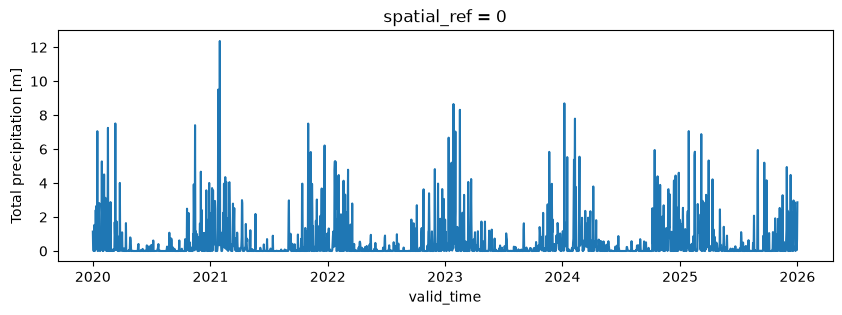

In [24]:
# Guardo valores máximos de precipitación y ploteo

fig, ax = plt.subplots(figsize=(10, 3))

# --
tpp_spatial_medn = ds_tpp_clip.sel(longitude=slice(-64.6, -64.4), latitude=slice(-31.4, -31.2)).median(dim=['latitude', 'longitude'])
tpp_spatial_medn = tpp_spatial_medn.sel(valid_time=slice('2020-01-01', '2026-01-01'))
'''
Accumulated liquid and frozen water, including rain and snow, that falls to the Earth's surface. It is the sum of large-scale precipitation 
(that precipitation which is generated by large-scale weather patterns, such as troughs and cold fronts) and convective precipitation (generated 
by convection which occurs when air at lower levels in the atmosphere is warmer and less dense than the air above, so it rises). Precipitation 
variables do not include fog, dew or the precipitation that evaporates in the atmosphere before it lands at the surface of the Earth. 
This variable is accumulated from the beginning of the forecast time to the end of the forecast step. The units of precipitation are depth 
in metres. It is the depth the water would have if it were spread evenly over the grid box. Care should be taken when comparing model 
variables with observations, because observations are often local to a particular point in space and time, rather than representing averages 
over a model grid box and model time step.

Measurement at 00:00:00 is the accumulated for the day before
'''

tpp_spatial_medn_res = tpp_spatial_medn.resample(valid_time="1D").max() * 1000
tpp_total_daily = np.concatenate((tpp_spatial_medn_res.tp.values[1:], np.array([0])))

# --
tpp_spatial_medn_res.tp.plot(ax=ax)
#ax.plot(df_eda['dateTime'], rem_outl_std(np.array(df_eda['total_rain'])), marker='o', linestyle='none', label='')


### Llenado de gaps de datos precipitación estaciones

In [25]:
# Unificación de los datos de estaciones con los de era5
pera5 = tpp_total_daily

df_pp_era = pd.DataFrame({'yy-mm-dd': tpp_spatial_medn_res.valid_time.values.astype('datetime64[D]'),
                         'eraP': pera5})

df_pp_era_join = df_pp_era.merge(df_p_join, on='yy-mm-dd', how="left") 

<Axes: xlabel='yy-mm-dd'>

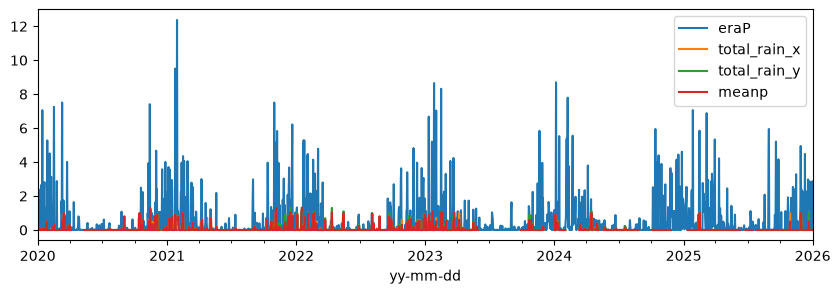

In [26]:
# Visualizo
df_pp_era_join.plot(x='yy-mm-dd', figsize=(10, 3))

In [27]:
# Evalúo correlación entre estaciones y era5
ppera5_mknan = df_pp_era_join['eraP'][~np.isnan(df_pp_era_join['meanp'])]
ppjoin_mknan = df_pp_era_join['meanp'][~np.isnan(df_pp_era_join['meanp'])]

# --
r, p = pearsonr(ppera5_mknan, ppjoin_mknan)
print(f"r = {r:.3f}, p = {p:.4f}")

r = 0.145, p = 0.0000


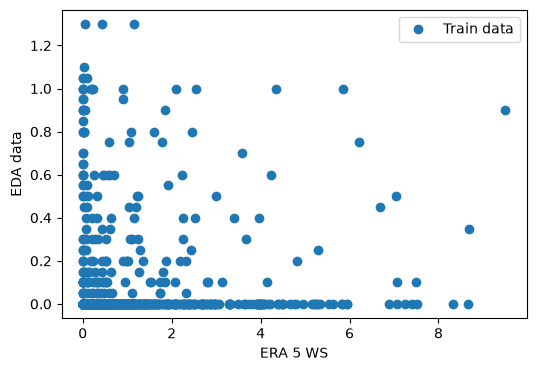

In [ ]:
# Visualizo correlación 
fig, ax = plt.subplots(figsize=(6, 4))

# --
ax.plot(ppera5_mknan, ppjoin_mknan, marker='o', linestyle='none', label='Train data')

# --
ax.set_xlabel('ERA 5 WS')
ax.set_ylabel('EDA data')
ax.legend(loc='best')

Conclusión: Por $R^{2}$ bajo, no se llena el gap con ERA5

###  Resumen para exportar

In [48]:
# Guardo los datos finales
time_values_norm_2326 = df_pp_era_join['yy-mm-dd']
pp_values_era5_2326 = np.array(df_pp_era_join['eraP'])

# --
print(time_values_norm_2326.shape, pp_values_era5_2326.shape)

(2193,) (2193,)


## Datos velocidad del viento

### Velocidad del viento estaciones

In [30]:
# Computo del promedio entre las estaciones
df_w_join = df_mcp[['dateTime', 'avg_windSpeed']].merge(df_eda[['dateTime', 'avg_windSpeed']], on='dateTime', how="left")
df_w_join['avg_windSpeed_x'] = df_w_join['avg_windSpeed_x'] * 0.277778
df_w_join['avg_windSpeed_y'] = df_w_join['avg_windSpeed_y'] * 0.277778

# --
df_w_join['meanW'] = df_w_join[['avg_windSpeed_x', 'avg_windSpeed_y']].mean(axis=1)

df_w_join['yy-mm-dd'] = np.array(df_w_join['dateTime']).astype('datetime64[D]')
df_w_join = df_w_join.drop(columns=['dateTime'])

# --
df_w_join_plot = df_w_join.copy()

/tmp/ipykernel_11722/1891516641.py:9: UserWarning: no explicit representation of timezones available for np.datetime64
  df_w_join['yy-mm-dd'] = np.array(df_w_join['dateTime']).astype('datetime64[D]')


<Axes: xlabel='yy-mm-dd'>

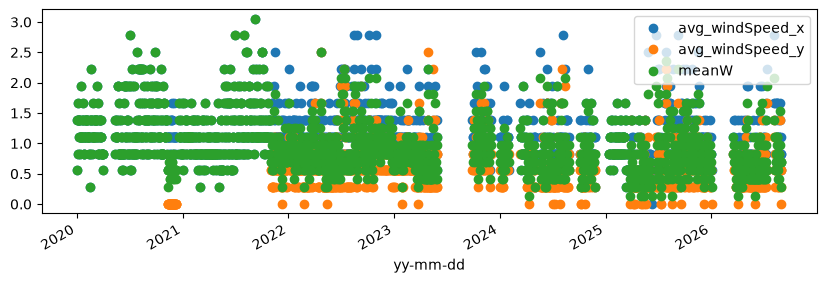

In [ ]:
# Visualizo
df_w_join.plot(x='yy-mm-dd', marker='o', linestyle='none', figsize=(10, 3))

### Exploración datos velocidad del viento ERA5

In [31]:
# Vector ESR
esr_vector = gpd.read_file('https://github.com/francobarrionuevoenv21/MAIE_devs_pub/raw/refs/heads/main/Proc_Img/tp_final_claS2/data/esr_clean.geojson').to_crs('EPSG:4326')

# Datos velocidad del viento ERA5
ds_w = xr.open_dataset('data/reanalysis-era5-land-timeseries-sfc-wind529wrpgo.nc')

In [32]:
# Clip datos
ds_w = ds_w.rio.set_spatial_dims(x_dim='longitude', y_dim='latitude', inplace=False)
ds_w = ds_w.rio.write_crs("EPSG:4326", inplace=False)
ds_w_clip = ds_w.rio.clip(esr_vector.geometry, all_touched=True)

/home/franco-barrionuevo/miniconda3/envs/sar_maie/lib/python3.14/site-packages/rasterio/features.py:381: ShapeSkipWarning: Invalid shape will not be rasterized: geometry={'type': 'MultiPolygon', 'coordinates': []}, index=0, value=1, error=ValueError('Input is not a valid geometry object')
  _rasterize(
/home/franco-barrionuevo/miniconda3/envs/sar_maie/lib/python3.14/site-packages/rasterio/features.py:381: ShapeSkipWarning: Invalid shape will not be rasterized: geometry={'type': 'MultiPolygon', 'coordinates': []}, index=1, value=1, error=ValueError('Input is not a valid geometry object')
  _rasterize(
/home/franco-barrionuevo/miniconda3/envs/sar_maie/lib/python3.14/site-packages/rasterio/features.py:381: ShapeSkipWarning: Invalid shape will not be rasterized: geometry={'type': 'MultiPolygon', 'coordinates': []}, index=2, value=1, error=ValueError('Input is not a valid geometry object')
  _rasterize(
/home/franco-barrionuevo/miniconda3/envs/sar_maie/lib/python3.14/site-packages/rasterio/

<Axes: title={'center': 'valid_time = 2017-12-31, spatial_ref = 0'}, xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>

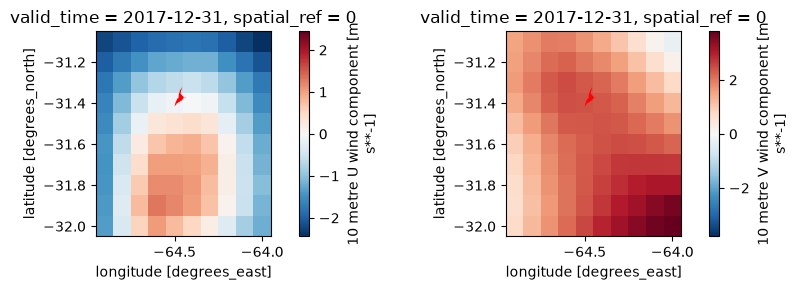

In [ ]:
# Visualización componentes una fecha
fig, ax = plt.subplots(1, 2, figsize=(10, 3), tight_layout=True)
ax = ax.flatten()

# --
ds_w.isel(valid_time=0).u10.plot(ax=ax[0])
esr_vector.dissolve().plot(ax=ax[0], color='red')

# --
ds_w.isel(valid_time=0).v10.plot(ax=ax[1])
esr_vector.dissolve().plot(ax=ax[1], color='red')

In [34]:
# Cómputo magnitud de la velocidad del viento
vel_mag = xr.ufuncs.sqrt(ds_w.u10**2+ds_w.v10**2)

<Axes: title={'center': 'valid_time = 2017-12-31, spatial_ref = 0'}, xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>

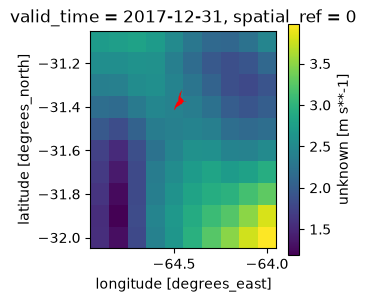

In [35]:
# Visualización magnitud velocidad del viento
fig, ax = plt.subplots(figsize=(3, 3))

# --
vel_mag.isel(valid_time=0).plot(ax=ax)
esr_vector.dissolve().plot(ax=ax, color='red')

In [36]:
# Clip datos
da_w = vel_mag.rio.set_spatial_dims(x_dim='longitude', y_dim='latitude', inplace=False)
da_w = da_w.rio.write_crs("EPSG:4326", inplace=False)
da_w_clip = da_w.rio.clip(esr_vector.geometry, all_touched=True)

/home/franco-barrionuevo/miniconda3/envs/sar_maie/lib/python3.14/site-packages/rasterio/features.py:381: ShapeSkipWarning: Invalid shape will not be rasterized: geometry={'type': 'MultiPolygon', 'coordinates': []}, index=0, value=1, error=ValueError('Input is not a valid geometry object')
  _rasterize(
/home/franco-barrionuevo/miniconda3/envs/sar_maie/lib/python3.14/site-packages/rasterio/features.py:381: ShapeSkipWarning: Invalid shape will not be rasterized: geometry={'type': 'MultiPolygon', 'coordinates': []}, index=1, value=1, error=ValueError('Input is not a valid geometry object')
  _rasterize(
/home/franco-barrionuevo/miniconda3/envs/sar_maie/lib/python3.14/site-packages/rasterio/features.py:381: ShapeSkipWarning: Invalid shape will not be rasterized: geometry={'type': 'MultiPolygon', 'coordinates': []}, index=2, value=1, error=ValueError('Input is not a valid geometry object')
  _rasterize(
/home/franco-barrionuevo/miniconda3/envs/sar_maie/lib/python3.14/site-packages/rasterio/

### Llenado de gaps de datos velocidad del viento estaciones

In [37]:
# Unificación de los datos de estaciones con los de era5
wera5 = da_w_clip.median(dim=['latitude', 'longitude']).resample(valid_time='1D').mean()
wera5 = wera5.sel(valid_time=slice('2020-01-01', '2026-01-01'))
#df_t_era5 = pd.DataFrame({'yy-mm-dd': })

df_w_era = pd.DataFrame({'yy-mm-dd': tera5.valid_time.values.astype('datetime64[D]'),
                         'eraW': wera5.values})

df_w_era_join = df_w_era.merge(df_w_join, on='yy-mm-dd', how="left")

<Axes: xlabel='yy-mm-dd'>

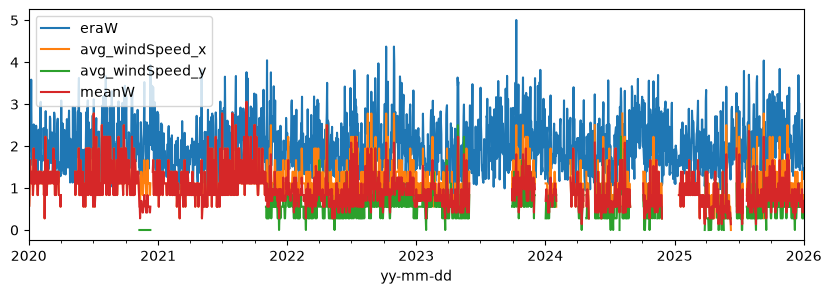

In [ ]:
# Visualización
df_w_era_join.plot(x='yy-mm-dd', figsize=(10, 3))

In [39]:
# Evalúo correlación entre estaciones y era5
wera5_mknan = df_w_era_join['eraW'][~np.isnan(df_w_era_join['meanW'])]
wjoin_mknan = df_w_era_join['meanW'][~np.isnan(df_w_era_join['meanW'])]

# --
r, p = pearsonr(wera5_mknan, wjoin_mknan)
print(f"r = {r:.3f}, p = {p:.4f}")

r = 0.593, p = 0.0000


In [40]:
# Genero un modelo lineal para predicción de los datos en los gaps
X = np.array(wera5_mknan).reshape(-1, 1)
y = np.array(wjoin_mknan).reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
model = LinearRegression().fit(X_train, y_train)
y_pred = model.predict(X_test)

#print(f"MAE = {mean_absolute_error(y_test, y_pred):.2f}")
print(f"R² = {r2_score(y_test, y_pred):.3f}")

R² = 0.305


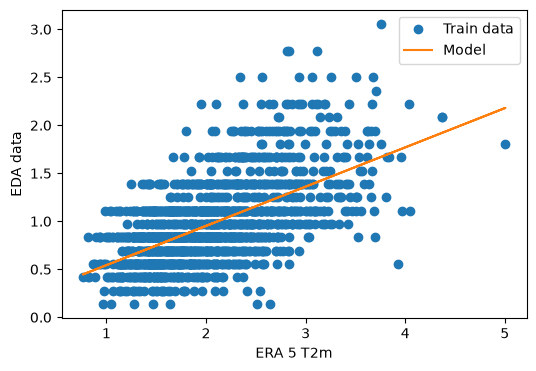

In [41]:
# Visualizo correlación
fig, ax = plt.subplots(figsize=(6, 4))

# --
ax.plot(X, wjoin_mknan, marker='o', linestyle='none', label='Train data')
ax.plot(X, model.predict(X.reshape(-1, 1)).reshape(-1), label='Model')
'''ax.plot(min_max_norm(X), min_max_norm(wjoin_mknan), marker='o', linestyle='none', label='Train data')
ax.plot(min_max_norm(X), min_max_norm(model.predict(X.reshape(-1, 1)).reshape(-1)), label='Model')
'''
# --
ax.set_xlabel('ERA 5 T2m')
ax.set_ylabel('EDA data')
ax.legend(loc='best')

In [42]:
# Enmascaro los datos y actualizo el dataset
mask = df_w_era_join['meanW'].isna()
preds = model.predict(df_w_era_join.loc[mask, 'eraW'].to_numpy().reshape(-1, 1))
df_w_era_join.loc[mask, 'meanW'] = preds

<Axes: xlabel='yy-mm-dd'>

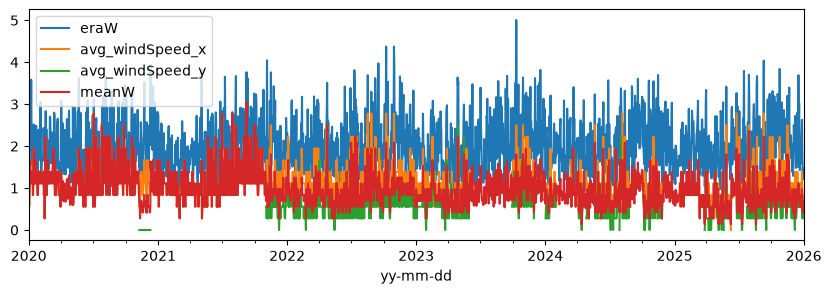

In [43]:
# Visualizo dataset final
df_w_era_join.plot(x='yy-mm-dd', figsize=(10, 3))

### Resumen para exportar

In [44]:
# Guardo los datos finales
time_values_norm_2326 = df_w_era_join['yy-mm-dd']
w_values_era5_2326 = df_w_era_join['eraW']
w_values_eda_2326 = df_w_era_join['meanW']

# --
print(time_values_norm_2326.shape, w_values_era5_2326.shape, w_values_eda_2326.shape)

(2193,) (2193,) (2193,)


## Merge de los datos y export

In [49]:
# --
df_merged = pd.DataFrame()

# --
df_merged['yy-mm-dd'] = time_values_norm_2326
df_merged['TP-ERA5_K'] = tp_values_era5_2326
df_merged['TP-EDAMCP_K'] = tp_values_eda_2326

# --
df_merged['PP-ERA5_mm'] = pp_values_era5_2326

# --
df_merged['WM-ERA5_ms'] = w_values_era5_2326
df_merged['WD-EDAMCP_ms'] = w_values_eda_2326

In [50]:
# --
df_merged.head(10)

,yy-mm-dd,TP-ERA5_K,TP-EDAMCP_K,PP-ERA5_mm,WM-ERA5_ms,WD-EDAMCP_ms
0,2020-01-01,295.672638,298.00,0.046566,2.063640,1.388890
1,2020-01-02,293.127289,295.25,0.016376,1.730708,0.555556
2,2020-01-03,294.136627,297.50,0.001578,1.696078,0.833334
3,2020-01-04,295.408447,298.50,0.000870,1.747064,1.388890
4,2020-01-05,297.788544,300.95,1.537986,2.566181,1.666668
5,2020-01-06,293.906403,295.15,0.000000,2.398733,1.388890
6,2020-01-07,294.418335,297.10,0.103697,2.612349,1.388890
7,2020-01-08,296.774445,300.00,0.152364,3.584239,1.388890
8,2020-01-09,296.315216,298.40,2.410516,2.341919,1.111112
9,2020-01-10,294.040161,297.15,0.102237,1.892733,1.111112


In [ ]:
# Export
df_merged.to_csv('output/meteo_merged_2326V4.csv', index=False)

# Plots report

**Open DR data**

In [51]:
# --
ds_rd = xr.open_dataset('data/reanalysis-era5-land-timeseries-sfc-radiation-heat_bau786p.nc')
ds_rd = ds_rd.rio.set_spatial_dims(x_dim='longitude', y_dim='latitude', inplace=False)
ds_rd = ds_rd.rio.write_crs("EPSG:4326", inplace=False)
ds_clip = ds_rd.rio.clip(esr_vector.geometry, all_touched=True)

/home/franco-barrionuevo/miniconda3/envs/sar_maie/lib/python3.14/site-packages/rasterio/features.py:381: ShapeSkipWarning: Invalid shape will not be rasterized: geometry={'type': 'MultiPolygon', 'coordinates': []}, index=0, value=1, error=ValueError('Input is not a valid geometry object')
  _rasterize(
/home/franco-barrionuevo/miniconda3/envs/sar_maie/lib/python3.14/site-packages/rasterio/features.py:381: ShapeSkipWarning: Invalid shape will not be rasterized: geometry={'type': 'MultiPolygon', 'coordinates': []}, index=1, value=1, error=ValueError('Input is not a valid geometry object')
  _rasterize(
/home/franco-barrionuevo/miniconda3/envs/sar_maie/lib/python3.14/site-packages/rasterio/features.py:381: ShapeSkipWarning: Invalid shape will not be rasterized: geometry={'type': 'MultiPolygon', 'coordinates': []}, index=2, value=1, error=ValueError('Input is not a valid geometry object')
  _rasterize(
/home/franco-barrionuevo/miniconda3/envs/sar_maie/lib/python3.14/site-packages/rasterio/

## ERA5 only

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


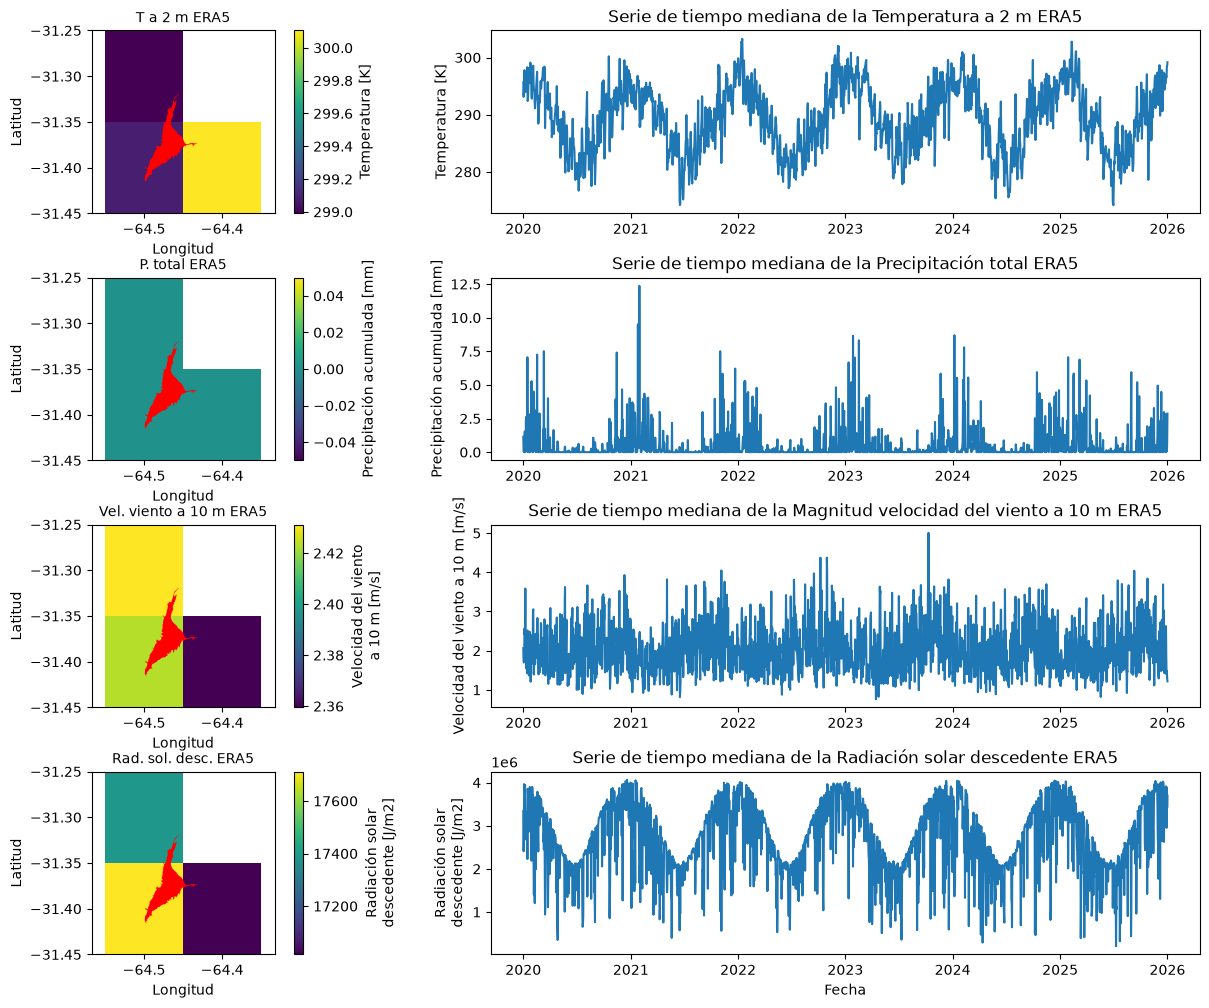

In [57]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(16, 12))

gs = fig.add_gridspec(
    4, 2,
    width_ratios=[1, 1.8],
    height_ratios=[1, 1, 1, 1],
    wspace=0.25,
    hspace=0.35
)

# Left: spatial maps
ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[1, 0])
ax2 = fig.add_subplot(gs[2, 0])
ax3 = fig.add_subplot(gs[3, 0])

# Right: time series
ax4 = fig.add_subplot(gs[0, 1])
ax5 = fig.add_subplot(gs[1, 1])
ax6 = fig.add_subplot(gs[2, 1])
ax7 = fig.add_subplot(gs[3, 1])


# ============================================================
# SPATIAL MAPS — LEFT
# ============================================================

cbar = ds_tp_clip.isel(valid_time=0).t2m.plot(ax=ax0)
cbar.colorbar.set_label('Temperatura [K]')
esr_vector.dissolve().plot(ax=ax0, color='red')
ax0.set_title('T a 2 m ERA5', fontsize=10)
ax0.set_xlabel('Longitud')
ax0.set_ylabel('Latitud')
ax0.set_box_aspect(1)


# --
cbar = ds_tpp_clip.isel(valid_time=0).tp.plot(ax=ax1)
cbar.colorbar.set_label('Precipitación acumulada [mm]')
esr_vector.dissolve().plot(ax=ax1, color='red')
ax1.set_title('P. total ERA5', fontsize=10)
ax1.set_xlabel('Longitud')
ax1.set_ylabel('Latitud')
ax1.set_box_aspect(1)


# --
cbar = da_w_clip.isel(valid_time=0).plot(ax=ax2)
cbar.colorbar.set_label('Velocidad del viento\na 10 m [m/s]')
esr_vector.dissolve().plot(ax=ax2, color='red')
ax2.set_title('Vel. viento a 10 m ERA5', fontsize=10)
ax2.set_xlabel('Longitud')
ax2.set_ylabel('Latitud')
ax2.set_box_aspect(1)


# --
cbar = ds_clip.isel(valid_time=0).ssrd.plot(ax=ax3)
cbar.colorbar.set_label('Radiación solar\ndescedente [J/m2]')
esr_vector.dissolve().plot(ax=ax3, color='red')
ax3.set_title('Rad. sol. desc. ERA5', fontsize=10)
ax3.set_xlabel('Longitud')
ax3.set_ylabel('Latitud')
ax3.set_box_aspect(1)


# ============================================================
# TIME SERIES — RIGHT
# ============================================================

tera5 = (
    ds_tp_clip
    .median(dim=['latitude', 'longitude'])
    .resample(valid_time='1D')
    .mean()
)

tera5 = tera5.t2m.sel(
    valid_time=slice('2020-01-01', '2026-01-01')
)

tera5.plot(ax=ax4)
ax4.set_title('Serie de tiempo mediana de la Temperatura a 2 m ERA5')
ax4.set_ylabel('Temperatura [K]')
ax4.set_xlabel(' ')


# --
tpp_spatial_medn = (
    ds_tpp_clip
    .sel(
        longitude=slice(-64.6, -64.4),
        latitude=slice(-31.4, -31.2)
    )
    .median(dim=['latitude', 'longitude'])
)

tpp_spatial_medn = tpp_spatial_medn.sel(
    valid_time=slice('2020-01-01', '2026-01-01')
)

tpp_spatial_medn = (
    tpp_spatial_medn
    .resample(valid_time='1D')
    .max() * 1000
)

tpp_spatial_medn.tp.plot(ax=ax5)
ax5.set_title('Serie de tiempo mediana de la Precipitación total ERA5')
ax5.set_ylabel('Precipitación acumulada [mm]')
ax5.set_xlabel(' ')


# --
wera5 = (
    da_w_clip
    .median(dim=['latitude', 'longitude'])
    .resample(valid_time='1D')
    .mean()
)

wera5 = wera5.sel(
    valid_time=slice('2020-01-01', '2026-01-01')
)

wera5.plot(ax=ax6)
ax6.set_title(
    'Serie de tiempo mediana de la Magnitud velocidad del viento a 10 m ERA5'
)
ax6.set_ylabel('Velocidad del viento a 10 m [m/s]')
ax6.set_xlabel(' ')


# --
rd_spatial_medn = (
    ds_clip.ssrd
    .median(dim=['latitude', 'longitude'])
    .sel(valid_time=slice('2020-01-01', '2026-01-01'))
)

rd_spatial_medn_res = (
    rd_spatial_medn
    .resample(valid_time='1D')
    .max()
)

rd_spatial_medn_res.plot(ax=ax7)
ax7.set_title(
    'Serie de tiempo mediana de la Radiación solar descedente ERA5'
)
ax7.set_ylabel('Radiación solar\ndescedente [J/m2]')
ax7.set_xlabel('Fecha')


plt.show()

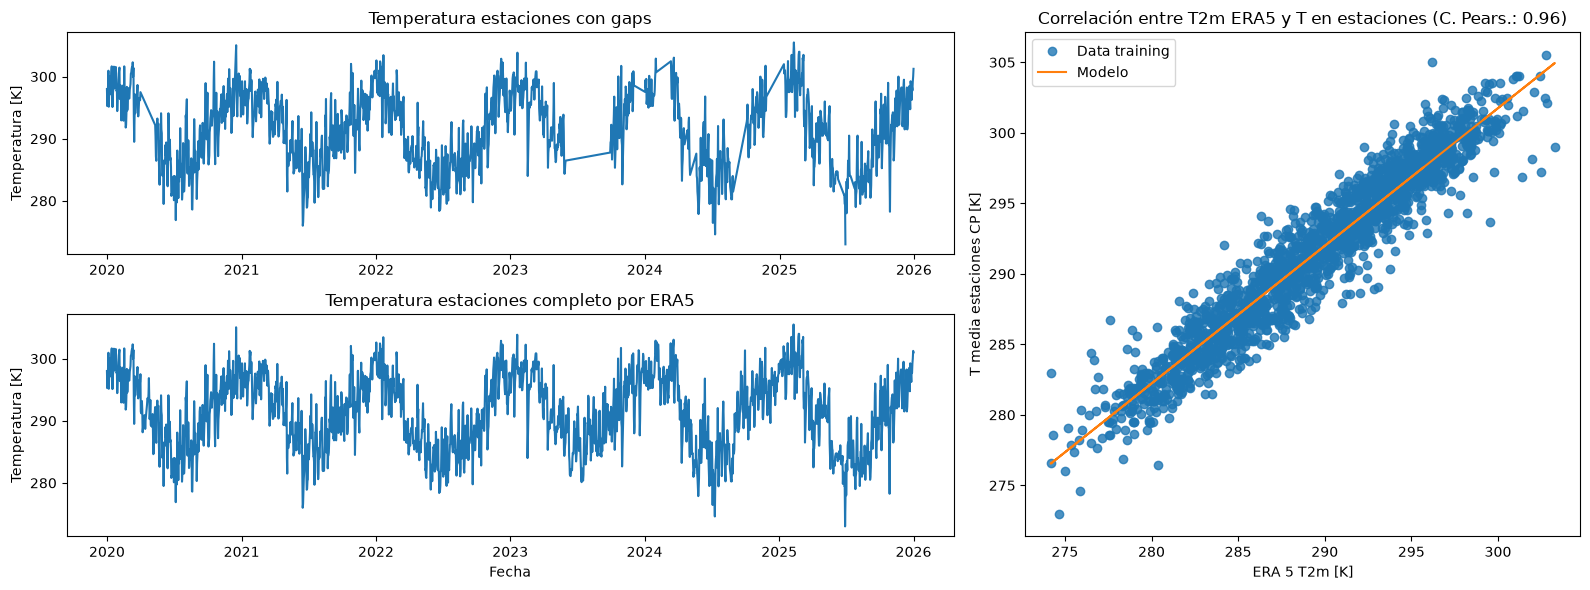

In [105]:
# --
date_situ_gap, t_situ_gap = np.array(df_t_join_plot['yy-mm-dd']), np.array(df_t_join_plot['meanT'])
date_situ_fill, t_situ_fill = np.array(df_t_era_join['yy-mm-dd']), np.array(df_t_era_join['meanT'])


fig = plt.figure(figsize=(16, 6))

gs = fig.add_gridspec(
    2, 2,
    width_ratios=[1.6, 1],
    height_ratios=[1, 1]
)

# Left - top
ax1 = fig.add_subplot(gs[0, 0])

# Left - bottom
ax2 = fig.add_subplot(gs[1, 0])


# Right - spans both rows
ax3 = fig.add_subplot(gs[:, 1])

# Example plots
ax1.plot(date_situ_gap, t_situ_gap)
ax1.set_ylabel('Temperatura [K]')
ax1.set_title('Temperatura estaciones con gaps')

ax2.plot(date_situ_fill, t_situ_fill)
ax2.set_ylabel('Temperatura [K]')
ax2.set_xlabel('Fecha')
ax2.set_title('Temperatura estaciones completo por ERA5')

'''ax3.plot(min_max_norm(X), min_max_norm(tjoin_mknan), marker='o', linestyle='none', label='Train data', alpha=0.7)
ax3.plot(min_max_norm(X), min_max_norm(model.predict(X.reshape(-1, 1)).reshape(-1)), label='Model')'''
ax3.plot(X, tjoin_mknan, marker='o', linestyle='none', label='Data training', alpha=0.8)
ax3.plot(X, model.predict(X.reshape(-1, 1)).reshape(-1), label='Modelo')
ax3.set_xlabel('ERA 5 T2m [K]')
ax3.set_ylabel('T media estaciones CP [K]')
ax3.legend(loc='best')
ax3.set_title('Correlación entre T2m ERA5 y T en estaciones (C. Pears.: 0.96)')

plt.tight_layout()
plt.show()

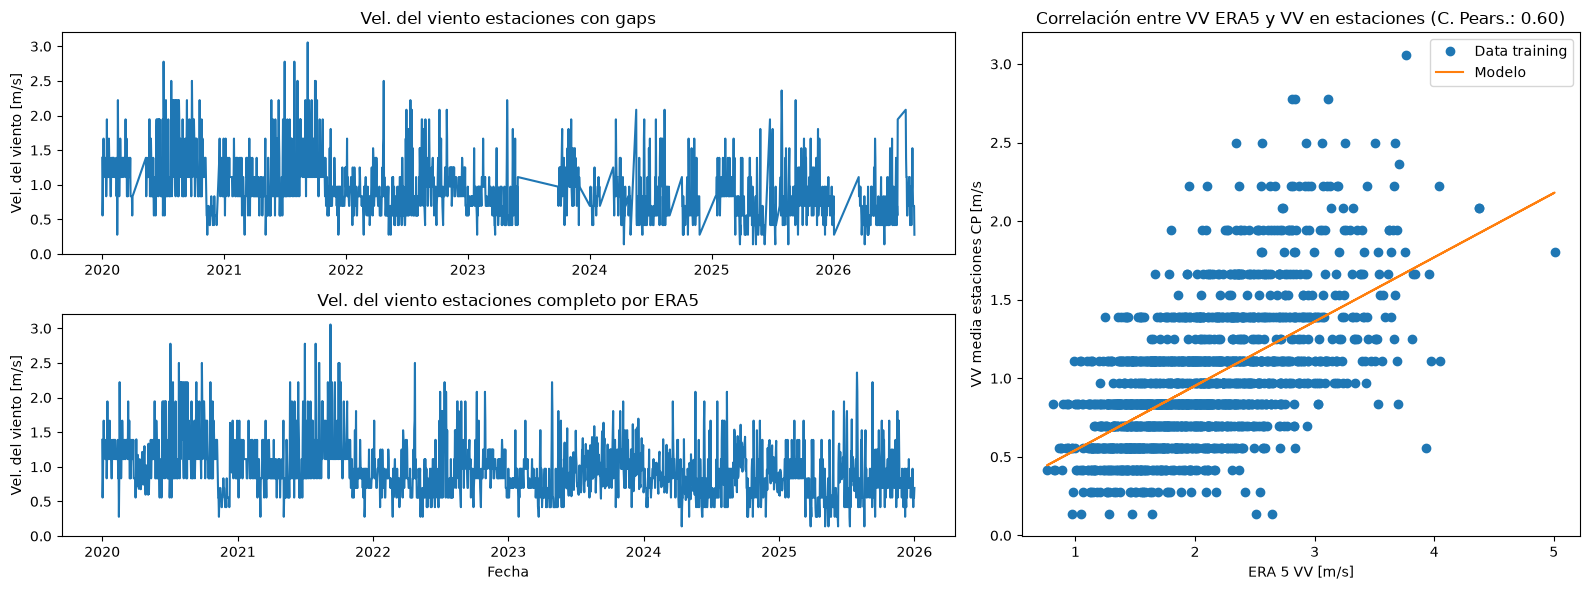

In [101]:
# --
date_situ_gap, t_situ_gap = np.array(df_w_join_plot['yy-mm-dd']), np.array(df_w_join_plot['meanW'])
date_situ_fill, t_situ_fill = np.array(df_w_era_join['yy-mm-dd']), np.array(df_w_era_join['meanW'])


fig = plt.figure(figsize=(16, 6))

gs = fig.add_gridspec(
    2, 2,
    width_ratios=[1.6, 1],
    height_ratios=[1, 1]
)

# Left - top
ax1 = fig.add_subplot(gs[0, 0])

# Left - bottom
ax2 = fig.add_subplot(gs[1, 0])


# Right - spans both rows
ax3 = fig.add_subplot(gs[:, 1])

# Example plots
ax1.plot(date_situ_gap, t_situ_gap)
ax1.set_ylabel('Vel. del viento [m/s]')
ax1.set_title('Vel. del viento estaciones con gaps')

ax2.plot(date_situ_fill, t_situ_fill)
ax2.set_ylabel('Vel. del viento [m/s]')
ax2.set_xlabel('Fecha')
ax2.set_title('Vel. del viento estaciones completo por ERA5')

ax3.plot(X, wjoin_mknan, marker='o', linestyle='none', label='Data training')
ax3.plot(X, model.predict(X.reshape(-1, 1)).reshape(-1), label='Modelo')
ax3.set_xlabel('ERA 5 VV [m/s]')
ax3.set_ylabel('VV media estaciones CP [m/s')
ax3.legend(loc='best')
ax3.set_title('Correlación entre VV ERA5 y VV en estaciones (C. Pears.: 0.60)')

plt.tight_layout()
plt.show()